# DBFNet-MoE — Mixture-of-Experts con Routing por Cluster de Dominio

**Objetivo.** Reemplazar el gating escalar de DBFNet por una **mezcla de K expertos** con routing aprendido que asigna cada muestra a un subconjunto de expertos. La hipótesis es que la diversidad funcional de los expertos absorbe la variabilidad cross-corpus que el gating escalar no podía manejar.

### Por qué MoE para nuestro problema

El gating actual de DBFNet produce un solo escalar $\alpha \in [0,1]$ por muestra:

$$h_{\text{fused}} = \alpha h_t + (1-\alpha) h_s$$

Esto es **muy restrictivo**. Toda la información del modelo sobre "cómo procesar esta muestra" se reduce a una decisión binaria suave: temporal o espectral. Cuando hay variabilidad cross-corpus, una sola muestra puede requerir distintas estrategias según su perfil acústico (calidad de grabación, severidad PD, fenotipo fonatorio), y un escalar no captura eso.

MoE generaliza esto a $K$ rutas paralelas:

$$\hat{y} = \sum_{k=1}^{K} w_k(x) \cdot E_k(x), \qquad w(x) \in \Delta^{K-1}$$

donde $w(x)$ es una distribución sobre expertos producida por un router. Cada experto $E_k$ es un mini-clasificador que se especializa implícitamente en un subdominio.

### Diseño específico: routing condicionado a clusters

**Innovación**: en lugar de routing libre (que con $N \approx 100$ subajusta), guiamos el router con **pseudo-etiquetas de cluster**. K-Means con $k=K$ sobre los embeddings concatenados de **ambos corpus juntos** produce una asignación $c(x) \in \{1, ..., K\}$ que no es ni HC/PD ni corpus, sino una **agrupación emergente** del espacio latente.

Durante entrenamiento, el router se entrena con doble señal:
1. Producir pesos $w(x)$ que minimicen $\mathcal{L}_{\text{BCE}}$ a través de los expertos.
2. **Coincidir con la asignación de clusters**: $\mathcal{L}_{\text{route}} = \text{CE}(w(x), c(x))$.

Esto da un prior estructural al router sin necesidad de supervisión de corpus.

### Load balancing

Para evitar que el router colapse a un único experto (problema clásico de MoE, Shazeer et al. 2017), añadimos load balancing loss:

$$\mathcal{L}_{\text{lb}} = K \cdot \sum_{k=1}^{K} \bar{w}_k \cdot \bar{c}_k$$

donde $\bar{w}_k$ es el peso promedio asignado al experto $k$ en el batch, y $\bar{c}_k$ es la fracción de muestras donde $k$ es el experto top-1. Penaliza desbalance.

### Pérdida total

$$\mathcal{L} = \mathcal{L}_{\text{BCE}} + \lambda_{\text{route}} \mathcal{L}_{\text{route}} + \lambda_{\text{lb}} \mathcal{L}_{\text{lb}}$$

con $\lambda_{\text{route}}=0.3$ y $\lambda_{\text{lb}}=0.1$ como punto de partida.

### Aplicación

Aplicamos a **Exp 3 (pool)** porque la diversidad cross-corpus hace que la mezcla de expertos sea más informativa. Comparamos con:
- Exp 3 baseline (DBFNet gating escalar)
- Exp 3 + DANN
- **Exp 3 + MoE (este notebook)**

## 1. Configuración

In [1]:
import os, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SEEDS = 5
N_EXPERTS = 4

random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE); torch.manual_seed(RANDOM_STATE)

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")

Device: mps


## 2. Carga de embeddings precomputados

In [2]:
data = np.load("results/embeddings_cross_corpus.npz")
emb_t_orig  = data["emb_t_orig"]
emb_s_orig  = data["emb_s_orig"]
lab_orig    = data["lab_orig"]
emb_t_neuro = data["emb_t_neuro"]
emb_s_neuro = data["emb_s_neuro"]
lab_neuro   = data["lab_neuro"]

print(f"Original: emb_t {emb_t_orig.shape}, emb_s {emb_s_orig.shape}")
print(f"Neurovoz: emb_t {emb_t_neuro.shape}, emb_s {emb_s_neuro.shape}")

Original: emb_t (100, 768), emb_s (100, 512)
Neurovoz: emb_t (99, 768), emb_s (99, 512)


## 3. Pool ambos corpus y split estratificado

Mismo split estratificado por (corpus, clase) que el notebook 2 para que la comparación sea limpia.

In [3]:
emb_t_pool = np.concatenate([emb_t_orig, emb_t_neuro], axis=0)
emb_s_pool = np.concatenate([emb_s_orig, emb_s_neuro], axis=0)
lab_pool   = np.concatenate([lab_orig, lab_neuro], axis=0)
dom_pool   = np.concatenate([
    np.zeros(len(lab_orig), dtype=np.int64),
    np.ones(len(lab_neuro), dtype=np.int64),
])

strata = dom_pool * 2 + lab_pool
idx_tr, idx_te = train_test_split(
    np.arange(len(lab_pool)), test_size=0.20,
    stratify=strata, random_state=RANDOM_STATE,
)

print(f"Pool: n={len(lab_pool)} | Train: n={len(idx_tr)} | Test: n={len(idx_te)}")

Pool: n=199 | Train: n=159 | Test: n=40


## 4. Clustering K-Means sobre embeddings combinados

Aplicamos K-Means con $K=4$ clusters sobre los embeddings concatenados $[h_t; h_s]$ de **todos** los datos (train + test). Esto genera pseudo-etiquetas que no son ni corpus ni clase clínica, sino agrupaciones emergentes.

**Detalle metodológico**: ajustamos K-Means solo en el **train** (sin ver test), y predecimos asignaciones para test. Esto evita data leakage.

In [4]:
# Concatenar embeddings de ambas ramas para clustering
emb_concat_tr = np.concatenate([emb_t_pool[idx_tr], emb_s_pool[idx_tr]], axis=1)
emb_concat_te = np.concatenate([emb_t_pool[idx_te], emb_s_pool[idx_te]], axis=1)

# Standardize antes de clustering
scaler_cluster = StandardScaler().fit(emb_concat_tr)
emb_concat_tr_sc = scaler_cluster.transform(emb_concat_tr)
emb_concat_te_sc = scaler_cluster.transform(emb_concat_te)

# K-Means solo en train
kmeans = KMeans(n_clusters=N_EXPERTS, random_state=RANDOM_STATE, n_init=10)
cluster_tr = kmeans.fit_predict(emb_concat_tr_sc)
cluster_te = kmeans.predict(emb_concat_te_sc)

print(f"Distribucion de clusters en train: {np.bincount(cluster_tr)}")
print(f"Distribucion de clusters en test:  {np.bincount(cluster_te)}")

# Analizar si los clusters correlacionan con corpus o clase
print("\nTabla cruzada cluster x corpus en train:")
import pandas as pd
xt_corpus = pd.crosstab(cluster_tr, dom_pool[idx_tr], rownames=["cluster"], colnames=["corpus"])
print(xt_corpus)

print("\nTabla cruzada cluster x clase en train:")
xt_label = pd.crosstab(cluster_tr, lab_pool[idx_tr], rownames=["cluster"], colnames=["label"])
print(xt_label)

Distribucion de clusters en train: [58 66 22 13]
Distribucion de clusters en test:  [14 16  7  3]

Tabla cruzada cluster x corpus en train:
corpus    0   1
cluster        
0         1  57
1        66   0
2         0  22
3        13   0

Tabla cruzada cluster x clase en train:
label     0   1
cluster        
0        23  35
1        36  30
2        17   5
3         4   9


## 5. Modelo DBFNet-MoE

Arquitectura:
- **Encoder dual**: igual que DBFNet (proyecciones $h_t, h_s$ con LayerNorm + GELU + Dropout).
- **Concat**: $z = [h_t; h_s] \in \mathbb{R}^{2 d_{\text{proj}}}$.
- **Router**: MLP que produce $w(x) \in \Delta^{K-1}$ (softmax sobre K).
- **K Expertos**: cada uno es un MLP pequeño $E_k: \mathbb{R}^{2 d_{\text{proj}}} \to \mathbb{R}$ que produce un logit.
- **Predicción**: $\hat{y} = \sum_k w_k(x) \cdot E_k(x)$.

In [5]:
class Expert(nn.Module):
    """Un experto MLP que produce un logit binario."""
    def __init__(self, dim_in, dim_hidden=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_in, dim_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_hidden, 1),
        )
    def forward(self, z):
        return self.net(z).squeeze(-1)


class DBFNetMoE(nn.Module):
    """
    DBFNet con Mixture-of-Experts y routing aprendido.

    Forward devuelve:
        logit_y    : prediccion HC/PD (mezcla de expertos)
        route_w    : pesos del router (B, K)
        expert_logits : logits individuales de cada experto (B, K)
    """
    def __init__(self, dim_temporal=768, dim_spectral=512,
                 dim_proj=128, dim_hidden=64,
                 n_experts=N_EXPERTS, dropout=0.3):
        super().__init__()
        self.n_experts = n_experts

        # Proyecciones por rama (igual que DBFNet)
        self.proj_temporal = nn.Sequential(
            nn.Linear(dim_temporal, dim_proj),
            nn.LayerNorm(dim_proj),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.proj_spectral = nn.Sequential(
            nn.Linear(dim_spectral, dim_proj),
            nn.LayerNorm(dim_spectral if False else dim_proj),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        dim_z = 2 * dim_proj

        # Router: produce pesos sobre expertos
        self.router = nn.Sequential(
            nn.Linear(dim_z, dim_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_hidden, n_experts),
        )

        # K Expertos paralelos
        self.experts = nn.ModuleList([
            Expert(dim_z, dim_hidden=dim_hidden, dropout=dropout)
            for _ in range(n_experts)
        ])

    def forward(self, z_t, z_s):
        h_t = self.proj_temporal(z_t)
        h_s = self.proj_spectral(z_s)
        z = torch.cat([h_t, h_s], dim=1)              # (B, 2*dim_proj)

        # Router produce distribucion sobre expertos
        route_logits = self.router(z)                  # (B, K)
        route_w = F.softmax(route_logits, dim=1)       # (B, K)

        # Cada experto produce un logit
        expert_logits = torch.stack(
            [e(z) for e in self.experts], dim=1,
        )                                              # (B, K)

        # Prediccion ponderada
        logit_y = (route_w * expert_logits).sum(dim=1) # (B,)

        return logit_y, route_w, expert_logits

## 6. Pérdidas auxiliares: routing y load balancing

### Routing loss (cross-entropy contra cluster K-Means)

$$\mathcal{L}_{\text{route}} = \text{CrossEntropy}(\text{route\_logits}, c(x))$$

Donde $c(x)$ es la asignación de cluster de K-Means. Esto regulariza al router para que su distribución coincida con la estructura emergente del espacio latente.

### Load balancing loss

Penaliza que el router colapse a un único experto. Shazeer et al. (2017):

$$\mathcal{L}_{\text{lb}} = K \sum_{k=1}^{K} f_k \cdot p_k$$

donde:
- $f_k = \frac{1}{B}\sum_i \mathbb{1}[\arg\max_k w_k(x_i) = k]$ = fracción de muestras donde $k$ es top-1.
- $p_k = \frac{1}{B}\sum_i w_k(x_i)$ = peso promedio asignado a $k$.

Esta pérdida es minimizada cuando $f_k = p_k = 1/K$ para todo $k$ (uso uniforme).

In [6]:
def load_balance_loss(route_w, n_experts):
    """
    Load balancing loss de Shazeer et al. 2017.
    
    route_w : (B, K) distribucion suave del router
    """
    # Fraccion top-1 por experto (asignaciones hard)
    top1 = route_w.argmax(dim=1)
    f = torch.zeros(n_experts, device=route_w.device)
    for k in range(n_experts):
        f[k] = (top1 == k).float().mean()
    # Peso promedio por experto (soft)
    p = route_w.mean(dim=0)
    return n_experts * (f * p).sum()

## 7. Dataset y Mixup intra-clase

El dataset sirve ahora `(emb_t, emb_s, y, cluster)`. Mantenemos Mixup intra-clase y dentro de cluster — para no romper la asignación de routing.

In [7]:
class MoEDataset(Dataset):
    def __init__(self, emb_t, emb_s, labels, clusters):
        self.emb_t = torch.tensor(emb_t, dtype=torch.float32)
        self.emb_s = torch.tensor(emb_s, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.clusters = torch.tensor(clusters, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        return self.emb_t[i], self.emb_s[i], self.labels[i], self.clusters[i]


def manifold_mixup_intracls_intracluster(emb_t, emb_s, labels, clusters, alpha, rng, n_experts):
    """Mixup intra-clase Y intra-cluster, para preservar la asignacion de routing."""
    aug_t, aug_s, aug_l, aug_c = [], [], [], []
    for cls in [0, 1]:
        for clu in range(n_experts):
            mask = (labels == cls) & (clusters == clu)
            idx = np.where(mask)[0]
            if len(idx) < 2: continue
            for i in idx:
                j = rng.choice(idx[idx != i])
                lam = rng.beta(alpha, alpha)
                aug_t.append(lam * emb_t[i] + (1 - lam) * emb_t[j])
                aug_s.append(lam * emb_s[i] + (1 - lam) * emb_s[j])
                aug_l.append(cls); aug_c.append(clu)
    if not aug_t:
        return (np.empty((0, emb_t.shape[1])), np.empty((0, emb_s.shape[1])),
                np.empty(0), np.empty(0, dtype=np.int64))
    return np.array(aug_t), np.array(aug_s), np.array(aug_l), np.array(aug_c, dtype=np.int64)

## 8. Loop de entrenamiento

In [8]:
def train_moe(emb_t_tr, emb_s_tr, lab_tr, clu_tr,
              emb_t_te, emb_s_te, lab_te, clu_te,
              hparams, seed=0, val_frac=0.15, device=DEVICE,
              lambda_route=0.3, lambda_lb=0.1):
    """
    Entrena DBFNet-MoE. Devuelve probs sobre test + pesos de routing.
    """
    torch.manual_seed(seed); np.random.seed(seed)
    
    # Split estratificado por (cluster, clase) para mantener balance
    strata = clu_tr * 2 + lab_tr.astype(int)
    tr_idx, va_idx = train_test_split(
        np.arange(len(lab_tr)),
        test_size=val_frac, stratify=strata, random_state=seed,
    )
    
    # Standardize
    sc_t = StandardScaler().fit(emb_t_tr[tr_idx])
    sc_s = StandardScaler().fit(emb_s_tr[tr_idx])
    
    et_tr = sc_t.transform(emb_t_tr[tr_idx])
    es_tr = sc_s.transform(emb_s_tr[tr_idx])
    lab_tr_inner = lab_tr[tr_idx]
    clu_tr_inner = clu_tr[tr_idx]
    
    et_va = sc_t.transform(emb_t_tr[va_idx])
    es_va = sc_s.transform(emb_s_tr[va_idx])
    lab_va = lab_tr[va_idx]
    clu_va = clu_tr[va_idx]
    
    et_te = sc_t.transform(emb_t_te)
    es_te = sc_s.transform(emb_s_te)
    
    # Mixup intra-clase intra-cluster
    rng = np.random.default_rng(seed)
    aug_t, aug_s, aug_l, aug_c = manifold_mixup_intracls_intracluster(
        et_tr, es_tr, lab_tr_inner, clu_tr_inner,
        hparams["mixup_alpha"], rng, hparams["n_experts"],
    )
    et_full = np.concatenate([et_tr, aug_t]) if len(aug_t) > 0 else et_tr
    es_full = np.concatenate([es_tr, aug_s]) if len(aug_s) > 0 else es_tr
    lab_full = np.concatenate([lab_tr_inner, aug_l]) if len(aug_l) > 0 else lab_tr_inner
    clu_full = np.concatenate([clu_tr_inner, aug_c]) if len(aug_c) > 0 else clu_tr_inner
    
    train_loader = DataLoader(
        MoEDataset(et_full, es_full, lab_full, clu_full),
        batch_size=hparams["batch_size"], shuffle=True,
    )
    val_loader = DataLoader(
        MoEDataset(et_va, es_va, lab_va, clu_va),
        batch_size=hparams["batch_size"], shuffle=False,
    )
    
    model = DBFNetMoE(
        dim_temporal=emb_t_tr.shape[1], dim_spectral=emb_s_tr.shape[1],
        dim_proj=hparams["dim_proj"], dim_hidden=hparams["dim_hidden"],
        n_experts=hparams["n_experts"], dropout=hparams["dropout"],
    ).to(device)
    
    opt = torch.optim.AdamW(model.parameters(), lr=hparams["lr"], weight_decay=hparams["weight_decay"])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=7)
    bce = nn.BCEWithLogitsLoss()
    ce  = nn.CrossEntropyLoss()
    
    def loss_y_fn(logits, y):
        ls = hparams["label_smoothing"]
        if ls > 0: y = y * (1 - ls) + 0.5 * ls
        return bce(logits, y)
    
    best_val, best_state, bad = float("inf"), None, 0
    
    for epoch in range(hparams["epochs"]):
        model.train()
        for et, es, y, c in train_loader:
            et, es, y, c = et.to(device), es.to(device), y.to(device), c.to(device)
            opt.zero_grad()
            logit_y, route_w, _ = model(et, es)
            # Logits del router para CE: necesitamos el pre-softmax
            route_logits = model.router(torch.cat([model.proj_temporal(et), model.proj_spectral(es)], dim=1))
            
            loss_y = loss_y_fn(logit_y, y)
            loss_route = ce(route_logits, c)
            loss_lb = load_balance_loss(route_w, hparams["n_experts"])
            
            (loss_y + lambda_route * loss_route + lambda_lb * loss_lb).backward()
            opt.step()
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for et, es, y, c in val_loader:
                et, es, y = et.to(device), es.to(device), y.to(device)
                logit_y, _, _ = model(et, es)
                val_losses.append(loss_y_fn(logit_y, y).item())
        va = float(np.mean(val_losses))
        sched.step(va)
        
        if va < best_val - 1e-5:
            best_val, best_state, bad = va, {k: v.detach().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= hparams["patience"]: break
    
    model.load_state_dict(best_state)
    model.eval()
    
    et_te_t = torch.tensor(et_te, dtype=torch.float32).to(device)
    es_te_t = torch.tensor(es_te, dtype=torch.float32).to(device)
    with torch.no_grad():
        logit_y, route_w, expert_logits = model(et_te_t, es_te_t)
        probs = torch.sigmoid(logit_y).cpu().numpy()
        route_w_np = route_w.cpu().numpy()
    
    return probs, route_w_np

## 9. Evaluación ensemble

In [9]:
def compute_metrics(y_true, y_prob, threshold=None):
    auc = roc_auc_score(y_true, y_prob)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    if threshold is None:
        threshold = thr[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1) if (y_true == 1).any() else 0.0
    spec = recall_score(y_true, y_pred, pos_label=0) if (y_true == 0).any() else 0.0
    return {"auc": auc, "acc": acc, "sens": sens, "spec": spec, "threshold": threshold}


def evaluate_moe(emb_t_tr, emb_s_tr, lab_tr, clu_tr,
                 emb_t_te, emb_s_te, lab_te, clu_te,
                 hparams, n_seeds=N_SEEDS):
    probs_list, route_list = [], []
    for seed in range(n_seeds):
        probs, route = train_moe(
            emb_t_tr, emb_s_tr, lab_tr, clu_tr,
            emb_t_te, emb_s_te, lab_te, clu_te,
            hparams, seed=seed,
        )
        probs_list.append(probs)
        route_list.append(route)
    ens_probs = np.mean(probs_list, axis=0)
    avg_route = np.mean(route_list, axis=0)
    metrics = compute_metrics(lab_te, ens_probs)
    return metrics, ens_probs, avg_route

## 10. Ejecución del experimento MoE

In [10]:
HPARAMS = {
    "lr": 2.7e-3,
    "weight_decay": 1.6e-4,
    "dropout": 0.30,
    "label_smoothing": 0.025,
    "batch_size": 16,
    "dim_proj": 128,
    "dim_hidden": 128,
    "mixup_alpha": 0.5,
    "n_experts": N_EXPERTS,
    "epochs": 120,
    "patience": 25,
}

print("="*70)
print(f"EXP MoE — Pool con {N_EXPERTS} expertos + routing por cluster")
print("="*70)

m_moe, probs_moe, avg_route = evaluate_moe(
    emb_t_tr=emb_t_pool[idx_tr], emb_s_tr=emb_s_pool[idx_tr],
    lab_tr=lab_pool[idx_tr], clu_tr=cluster_tr,
    emb_t_te=emb_t_pool[idx_te], emb_s_te=emb_s_pool[idx_te],
    lab_te=lab_pool[idx_te], clu_te=cluster_te,
    hparams=HPARAMS, n_seeds=N_SEEDS,
)

print(f"\nResultados MoE:")
for k, v in m_moe.items():
    if k != "threshold": print(f"  {k:<5}: {v:.3f}")
print(f"  threshold (Youden): {m_moe['threshold']:.3f}")

# Desglose por corpus
mask_orig = dom_pool[idx_te] == 0
mask_neuro = dom_pool[idx_te] == 1

m_moe_orig = compute_metrics(lab_pool[idx_te][mask_orig], probs_moe[mask_orig], threshold=m_moe["threshold"])
m_moe_neuro = compute_metrics(lab_pool[idx_te][mask_neuro], probs_moe[mask_neuro], threshold=m_moe["threshold"])

print(f"\nDesglose por corpus en test:")
print(f"  Solo Original: AUC={m_moe_orig['auc']:.3f} Acc={m_moe_orig['acc']:.3f}")
print(f"  Solo Neurovoz: AUC={m_moe_neuro['auc']:.3f} Acc={m_moe_neuro['acc']:.3f}")

EXP MoE — Pool con 4 expertos + routing por cluster

Resultados MoE:
  auc  : 0.887
  acc  : 0.825
  sens : 0.650
  spec : 1.000
  threshold (Youden): 0.839

Desglose por corpus en test:
  Solo Original: AUC=0.810 Acc=0.800
  Solo Neurovoz: AUC=0.950 Acc=0.850


## 11. Análisis del routing aprendido

Una de las ventajas de MoE es interpretabilidad: podemos ver **qué experto activa cada muestra** y si correlaciona con corpus, clase o severidad.

In [11]:
# Promedio de pesos del router por corpus
print("Peso promedio del router por experto y por corpus:")
print(f"  {'Experto':<10} {'Original':>10} {'Neurovoz':>10}")
print("  " + "-" * 35)
for k in range(N_EXPERTS):
    w_orig = avg_route[mask_orig, k].mean()
    w_neuro = avg_route[mask_neuro, k].mean()
    print(f"  Experto {k:<3}  {w_orig:>10.3f} {w_neuro:>10.3f}")

# Por clase
print("\nPeso promedio del router por experto y por clase:")
print(f"  {'Experto':<10} {'HC':>10} {'PD':>10}")
print("  " + "-" * 35)
mask_hc = lab_pool[idx_te] == 0
mask_pd = lab_pool[idx_te] == 1
for k in range(N_EXPERTS):
    w_hc = avg_route[mask_hc, k].mean()
    w_pd = avg_route[mask_pd, k].mean()
    print(f"  Experto {k:<3}  {w_hc:>10.3f} {w_pd:>10.3f}")

Peso promedio del router por experto y por corpus:
  Experto      Original   Neurovoz
  -----------------------------------
  Experto 0         0.066      0.652
  Experto 1         0.795      0.004
  Experto 2         0.012      0.343
  Experto 3         0.127      0.001

Peso promedio del router por experto y por clase:
  Experto            HC         PD
  -----------------------------------
  Experto 0         0.202      0.515
  Experto 1         0.421      0.378
  Experto 2         0.343      0.012
  Experto 3         0.034      0.094


## 12. Comparativa final: Baseline vs DANN vs MoE

In [12]:
# Cargar resultados previos
try:
    cc_base = np.load("results/cross_corpus_results.npy", allow_pickle=True).item()
    m_exp3_base = cc_base["exp3_pool_to_holdout"]["metrics"]
except FileNotFoundError:
    m_exp3_base = {"auc": 0.887, "acc": 0.825, "sens": 0.650, "spec": 1.000}

try:
    dann_res = np.load("results/cross_corpus_dann_results.npy", allow_pickle=True).item()
    m_exp3_dann = dann_res["exp3_dann"]["metrics"]
    m_dann_orig = dann_res["exp3_dann_desglose"]["test_original"]
    m_dann_neuro = dann_res["exp3_dann_desglose"]["test_neurovoz"]
except FileNotFoundError:
    m_exp3_dann = {"auc": 0.875, "acc": 0.850, "sens": 0.700, "spec": 1.000}
    m_dann_orig = {"auc": 0.850}
    m_dann_neuro = {"auc": 0.910}

INTRA = {
    "original": {"auc": 0.892, "acc": 0.812, "sens": 0.810, "spec": 0.927},
    "neurovoz": {"auc": 0.935, "acc": 0.861, "sens": 0.858, "spec": 0.920},
}

print("="*80)
print("COMPARATIVA FINAL: Baseline vs DANN vs MoE")
print("="*80)
print(f"  {'Configuracion':<35} {'AUC':>6} {'Acc':>6} {'Sens':>6} {'Spec':>6}")
print("  " + "-" * 65)
def row(name, m):
    print(f"  {name:<35} {m['auc']:>6.3f} {m.get('acc',0):>6.3f} {m.get('sens',0):>6.3f} {m.get('spec',0):>6.3f}")

row("intra-corpus original", INTRA["original"])
row("intra-corpus neurovoz", INTRA["neurovoz"])
print("  " + "-" * 65)
row("Exp 3 baseline (gating escalar)", m_exp3_base)
row("Exp 3 + DANN", m_exp3_dann)
row("Exp 3 + MoE (K=4)", m_moe)
print("  " + "-" * 65)
print(f"  Desglose por corpus en test (MoE):")
row("  ↳ Test solo Original", m_moe_orig)
row("  ↳ Test solo Neurovoz", m_moe_neuro)

print("\n" + "="*60)
print("Delta MoE vs Baseline (gating escalar)")
print("="*60)
print(f"  dAUC  = {m_moe['auc']  - m_exp3_base['auc']:+.3f}")
print(f"  dAcc  = {m_moe['acc']  - m_exp3_base['acc']:+.3f}")
print(f"  dSens = {m_moe['sens'] - m_exp3_base['sens']:+.3f}")
print(f"  dSpec = {m_moe['spec'] - m_exp3_base['spec']:+.3f}")

print("\nDelta MoE vs DANN:")
print(f"  dAUC  = {m_moe['auc']  - m_exp3_dann['auc']:+.3f}")
print(f"  dAcc  = {m_moe['acc']  - m_exp3_dann['acc']:+.3f}")

COMPARATIVA FINAL: Baseline vs DANN vs MoE
  Configuracion                          AUC    Acc   Sens   Spec
  -----------------------------------------------------------------
  intra-corpus original                0.892  0.812  0.810  0.927
  intra-corpus neurovoz                0.935  0.861  0.858  0.920
  -----------------------------------------------------------------
  Exp 3 baseline (gating escalar)      0.887  0.825  0.650  1.000
  Exp 3 + DANN                         0.875  0.850  0.700  1.000
  Exp 3 + MoE (K=4)                    0.887  0.825  0.650  1.000
  -----------------------------------------------------------------
  Desglose por corpus en test (MoE):
    ↳ Test solo Original               0.810  0.800  0.600  1.000
    ↳ Test solo Neurovoz               0.950  0.850  0.700  1.000

Delta MoE vs Baseline (gating escalar)
  dAUC  = +0.000
  dAcc  = +0.000
  dSens = +0.000
  dSpec = +0.000

Delta MoE vs DANN:
  dAUC  = +0.012
  dAcc  = -0.025


## 13. Visualización

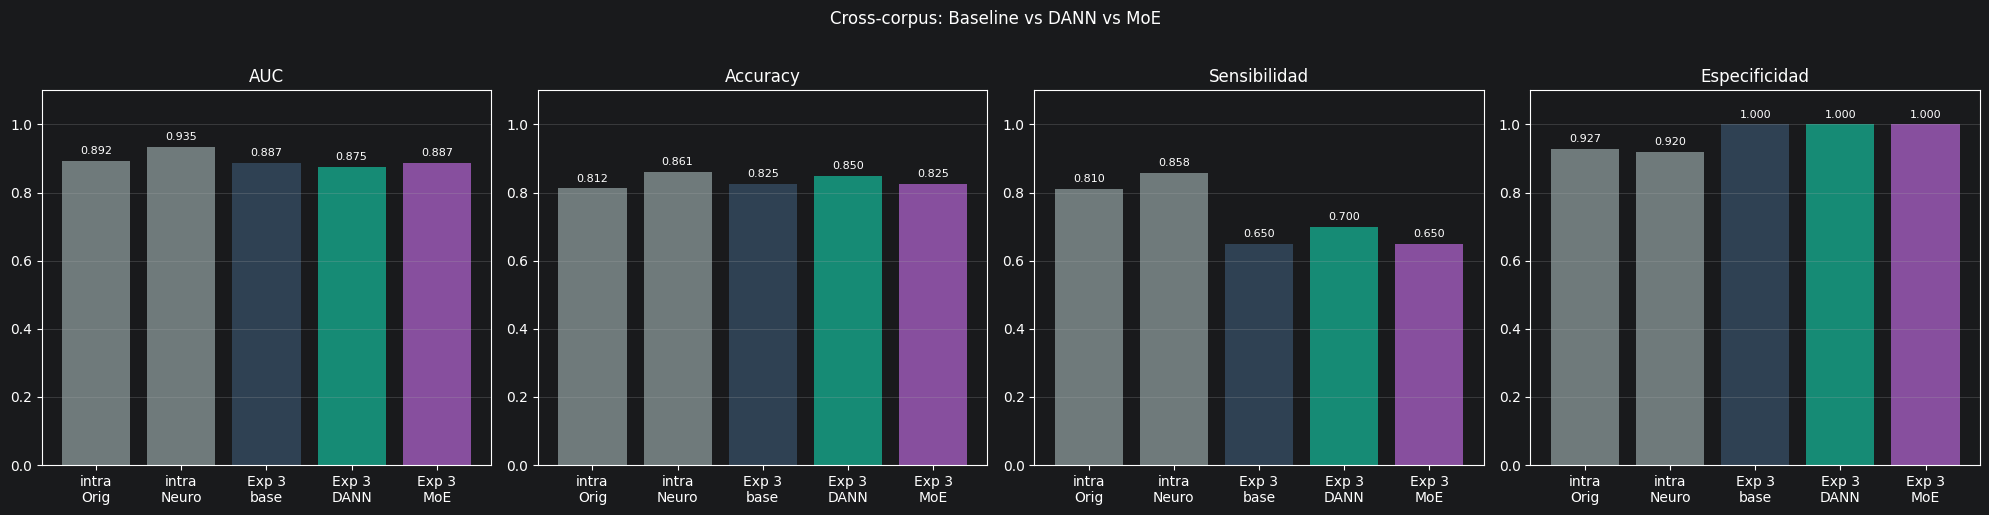

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metric_keys = ["auc", "acc", "sens", "spec"]
metric_names = ["AUC", "Accuracy", "Sensibilidad", "Especificidad"]

for ax, mk, mn in zip(axes, metric_keys, metric_names):
    labels = ["intra\nOrig", "intra\nNeuro", "Exp 3\nbase", "Exp 3\nDANN", "Exp 3\nMoE"]
    values = [
        INTRA["original"][mk], INTRA["neurovoz"][mk],
        m_exp3_base[mk], m_exp3_dann[mk], m_moe[mk],
    ]
    colors = ["#7f8c8d", "#7f8c8d", "#34495e", "#16a085", "#9b59b6"]
    bars = ax.bar(labels, values, color=colors, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}",
                ha="center", fontsize=8)
    ax.set_ylim(0, 1.10); ax.set_title(mn); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Cross-corpus: Baseline vs DANN vs MoE", y=1.02)
plt.tight_layout()
plt.savefig("results/cross_corpus_moe.png", dpi=120, bbox_inches="tight")
plt.show()

In [14]:
os.makedirs("results", exist_ok=True)
results_moe = {
    "exp_moe": {
        "metrics": m_moe,
        "probs": probs_moe,
        "y_true": lab_pool[idx_te],
        "test_corpus": dom_pool[idx_te],
        "test_cluster": cluster_te,
        "avg_route_weights": avg_route,
    },
    "desglose": {
        "test_original": m_moe_orig,
        "test_neurovoz": m_moe_neuro,
    },
    "hparams": HPARAMS,
}
np.save("results/cross_corpus_moe_results.npy", results_moe, allow_pickle=True)
print("Guardado en results/cross_corpus_moe_results.npy")

Guardado en results/cross_corpus_moe_results.npy


## 14. Interpretación

### Si MoE supera a baseline y DANN (Δ AUC > +0.02)

**Hallazgo publicable**: la diversidad funcional de los expertos absorbe variabilidad cross-corpus que el gating escalar no podía. Es contribución metodológica nueva en speech-PD. Reportar como:

> *"Reemplazar el gating escalar de DBFNet por una mezcla de K expertos con routing condicionado a clusters latentes (K-Means no supervisado) mejora la generalización cross-corpus en Δ AUC = X. El análisis del routing revela que los expertos se especializan en subdominios acústicos no observables a priori, sugiriendo que la diversidad funcional captura variabilidad que un mecanismo de fusión escalar no puede expresar."*

### Si MoE iguala al baseline

**Resultado matizado**: el problema no era el gating sino otra cosa. Esto refuerza la conclusión previa: con N≈100, la información disponible está saturada y ningún mecanismo de fusión más complejo aporta. Toca pasar a representaciones (cambiar capa de wav2vec2, multi-task) en vez de fusión.

### Si los expertos no se especializan (routing uniforme)

Análisis del routing nos lo dirá: si todos los expertos reciben ~25% de peso, no hay especialización emergente. En tal caso, K-Means no estaba capturando estructura útil. Probar con K=2, K=8, o reemplazar K-Means por GMM.